# Library Import

In [1]:
import numpy as np
import pandas as pd
from scipy.signal import butter, lfilter
import matplotlib.pyplot as plt
%matplotlib inline

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


# Set Sequence Name

In [2]:
sequence_name = "H13.00T3.0h36_RE_G"

In [3]:
sequences = {
    "H09.25T1.6h37_IR_G": {"gt_sync": (400, 9300), "pr_sync": (676, 9576)},
    "H11.25T2.8h35_IR_G": {"gt_sync": (600, 16800), "pr_sync": (558, 16798)},
    "H11.25T3.0h35_IR_G": {"gt_sync": (500, 18000), "pr_sync": (566, 18066)},
    "H11.50T2.2h35_IR_G": {"gt_sync": (300, 13200), "pr_sync": (1236, 14136)},
    "H12.50T2.8h35_RE_G": {"gt_sync": (100, 1050), "pr_sync": (252, 1202)},
    "H13.00T2.0h35_RE_G": {"gt_sync": (200, 850), "pr_sync": (463, 1113)},
    "H13.00T2.0h37_RE_G": {"gt_sync": (340, 1087), "pr_sync": (494, 1241)},
    "H13.00T2.2h35_RE_G": {"gt_sync": (100, 1050), "pr_sync": (316, 1266)},
    "H13.00T2.4h35_RE_G": {"gt_sync": (220, 880), "pr_sync": (391, 1051)},
    "H13.00T2.6h35_RE_G": {"gt_sync": (150, 1040), "pr_sync": (374, 1264)},
    "H13.00T2.6h36_RE_G": {"gt_sync": (200, 1100), "pr_sync": (660, 1560)},
    "H13.00T3.0h35_RE_G": {"gt_sync": (100, 1100), "pr_sync": (256, 1256)},
    "H13.00T3.0h36_RE_G": {"gt_sync": (150, 1130), "pr_sync": (275, 1255)},
}
gt_sync_index = sequences[sequence_name]["gt_sync"]
pr_sync_index = sequences[sequence_name]["pr_sync"]

# Utility Functions

In [4]:
def gt_remove_structure_height(gt, sequence_name):
    gt_true = np.copy(gt)
    for i in range(gt_true.shape[0]):
        if gt_true[i, 1] < 0:  # remove minus value
            gt_true[i, 1] = 0
    return gt_true

def show_height_graph_single(data, title, fig_size=(64, 12), font_size=20, line_width=4, line_color="C0"):
    plt.figure(figsize=fig_size)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.title(title, fontsize=font_size+6)
    plt.plot(data[:, 0], data[:, 1], linewidth=line_width, color=line_color)
    plt.show()

def show_height_graph_multiple(datas, title, fig_size=(64, 12), font_size=20):
    plt.figure(figsize=fig_size)
    plt.xticks(fontsize=font_size)
    y_max = 0
    for data in datas:
        max_value = data[0][:, 1].max()
        if max_value > y_max:
            y_max = max_value
    y_max = np.ceil(y_max)
#     y_max = 8
    plt.ylim(top=y_max)
    plt.yticks(fontsize=font_size)
    plt.title(title, fontsize=font_size+6)
    for data in datas:
        plt.plot(data[0][:, 1], label=data[1])
    plt.legend(fontsize=font_size)
    plt.show()

In [5]:
def low_pass_filter(series, low, order=1):
    '''
    series : 데이터
    low : 최저 구간(0< low < 1)
    order : 필터 계수, 높을수록 민감
    '''
    b, a = butter(N=order, Wn=low, btype='low')
    lpf_series = lfilter(b, a, series)
    return lpf_series

In [6]:
def calc_result(data):
    """
    Created on Wed Jul 12 20:34:39 2023

    @author: Coastal_LAB
    """
    eta = list(map(float, data))
    num = int(len(eta) / 5)
    num = int(num / 2)  #### 새로운 실험에서는 이 라인 주석처리

    h = []
    # test=[]

    Q = 0
    initial_h = 0.001  #### 새로운 실험에서는 5.3으로 변경
    hz = 50  # Observation rate:50Hz
    dt = 1/hz  # Sampling time:0.02s
    b = 0.31  # chute width
    etamax = -10
    icount = 0

    for k in range(0, num):
        h.append(eta[4*k+5]-initial_h)  #### 새로운 실험에서는 eta[6*k+5]-initial_h 으로 변경
        if h[k]>0:
            qdt = (9.81)**0.5*(h[k]/100)**1.5*dt*b  # [Unit=m^3/s/m]
            Q = qdt+Q
            icount = icount+1
        etamax = max(h)
    
    total_overtopping_volume = round(Q, 5)
    mean_overtopping_rate = round(Q/b/(icount*dt), 5)
    duration_of_overtopping = icount*dt
    max_overtopping_height = round(etamax, 3)
    
    return total_overtopping_volume, mean_overtopping_rate, duration_of_overtopping, max_overtopping_height

def show_result(gt_result, pr_result):
    variables = [  # 행 제목 리스트
        "Total Overtopping Volume   (m^3)",
        "Mean Overtopping Rate  (m^3/m/s)",
        "Duration of Overtopping    (sec)",
        "Max Overtopping Height      (cm)"
    ]

    data = {  # 데이터 프레임 생성
        "GT": [gt_result[i] for i in range(len(variables))],
        "PR": [pr_result[i] for i in range(len(variables))]
    }

    return pd.DataFrame(data, index=variables)

---

# Data Load

In [7]:
tracker_type = "iou"

In [8]:
gt_file_path = f"./{sequence_name}/{sequence_name}_label/gt/gt_height.csv"
pr_file_path = f"./{sequence_name}/{sequence_name}_wave_height_result_{tracker_type}.txt"

gt_df = pd.read_csv(gt_file_path, sep=",")
pr_df = pd.read_csv(pr_file_path, sep=" ", header=None)

gt = gt_df[["Time", "Eta"]].to_numpy()
pr = pr_df[[0, 3]].to_numpy()  # frame num, object id, height-px, height 

# Synchronize GT and Pr (Downsampling GT to 30Hz)

In [16]:
gt_hz = 50
pr_fps = 30
multiflying_factor = 5/9  # 안맞을 시, 그래프에서 최고높이 기준으로 비율 계산하면 됨

In [17]:
time_30Hz = np.arange(0, gt[-1, 0], 1/pr_fps)  # 최종 시간까지 0.033초 간격으로 시간 축 생성
height_30Hz = np.interp(time_30Hz, gt[:, 0], gt[:, 1])  # 보간을 통해 높이 데이터 생성
gt = np.vstack((time_30Hz, height_30Hz)).T
gt = gt_remove_structure_height(gt, sequence_name) # 구조물의 높이를 뺀 순수 월파고를 구함

# Pred의 비어있는 시간대의 월파고를 0으로 채움
data_len_temp = 2000
if "IR" in sequence_name:
    data_len_temp *= 10
temp_pr = np.zeros((data_len_temp, 2)) # IR : 20000 / RE : 2000
for i in range(temp_pr.shape[0]):
    temp_pr[i] = np.array([i+1, 0])
for i in range(pr.shape[0]):
    temp_pr[int(pr[i, 0])-1] = pr[i]
pr = temp_pr

gt_sync = gt
pr_sync = pr[20:data_len_temp]*multiflying_factor
gt_sync = gt_sync[gt_sync_index[0]:gt_sync_index[1]]
pr_sync = pr_sync[pr_sync_index[0]:pr_sync_index[1]]

# Show Result

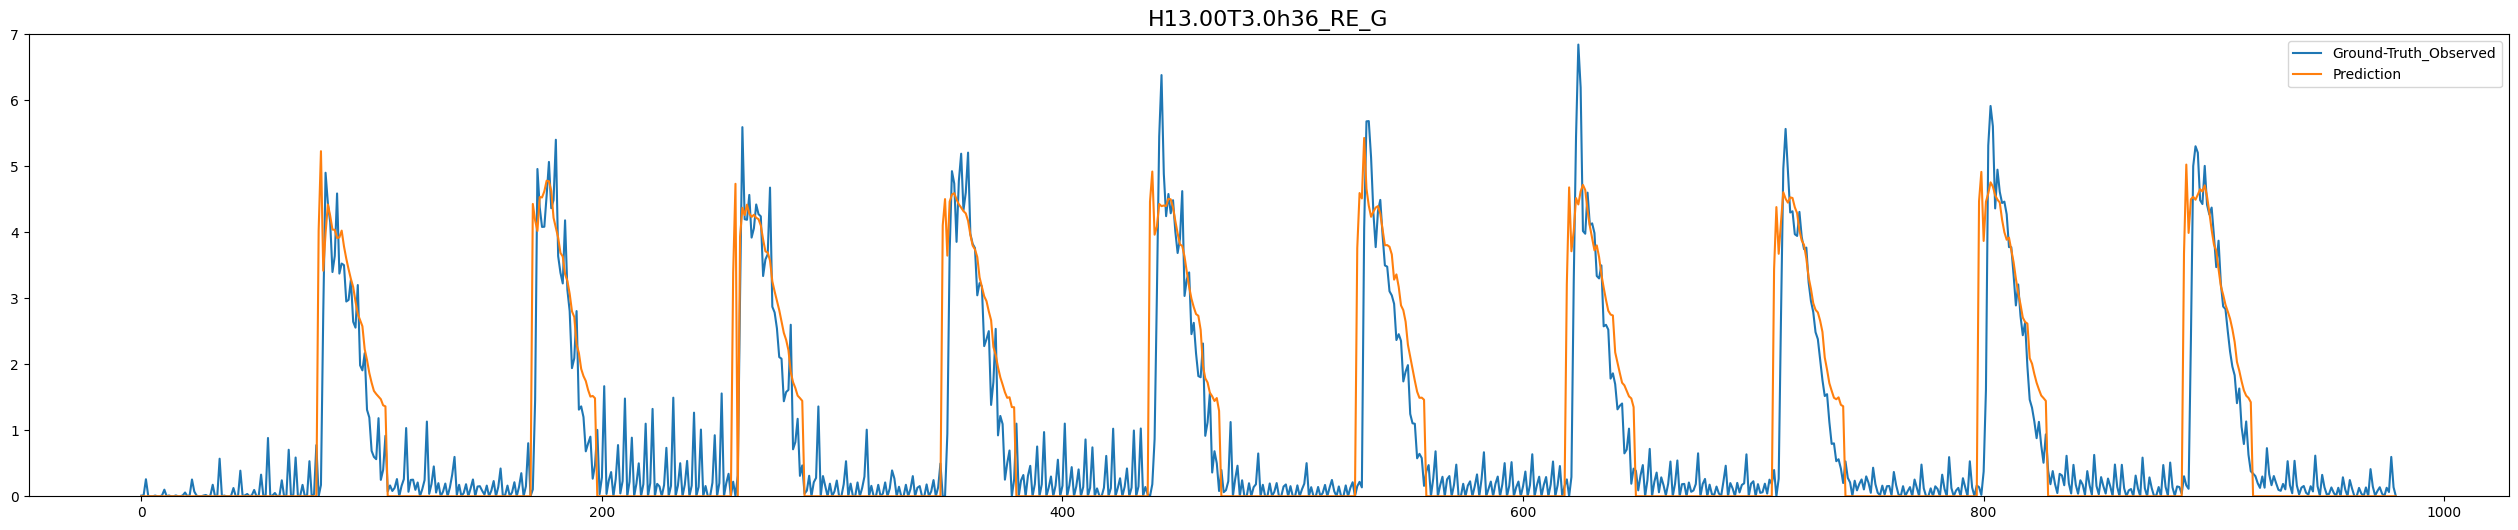

In [18]:
show_height_graph_multiple([[gt_sync, "Ground-Truth_Observed"], [pr_sync, "Prediction"]], f"{sequence_name}", fig_size=(32, 6), font_size=10)

In [19]:
print(show_result(calc_result(gt_sync[:, 1].tolist()), calc_result(pr_sync[:, 1].tolist())))

                                       GT       PR
Total Overtopping Volume   (m^3)  0.00312  0.00358
Mean Overtopping Rate  (m^3/m/s)  0.00708  0.01862
Duration of Overtopping    (sec)  1.42000  0.62000
Max Overtopping Height      (cm)  5.59200  4.77200


---

# Save GT and Prediction to CSV

In [13]:
np.savetxt(f"{sequence_name}_output_vis_gt.csv", gt_sync[:, 1], delimiter=",")
np.savetxt(f"{sequence_name}_output_vis_pr.csv", pr_sync[:, 1], delimiter=",")

---

# Apply LPF to GT

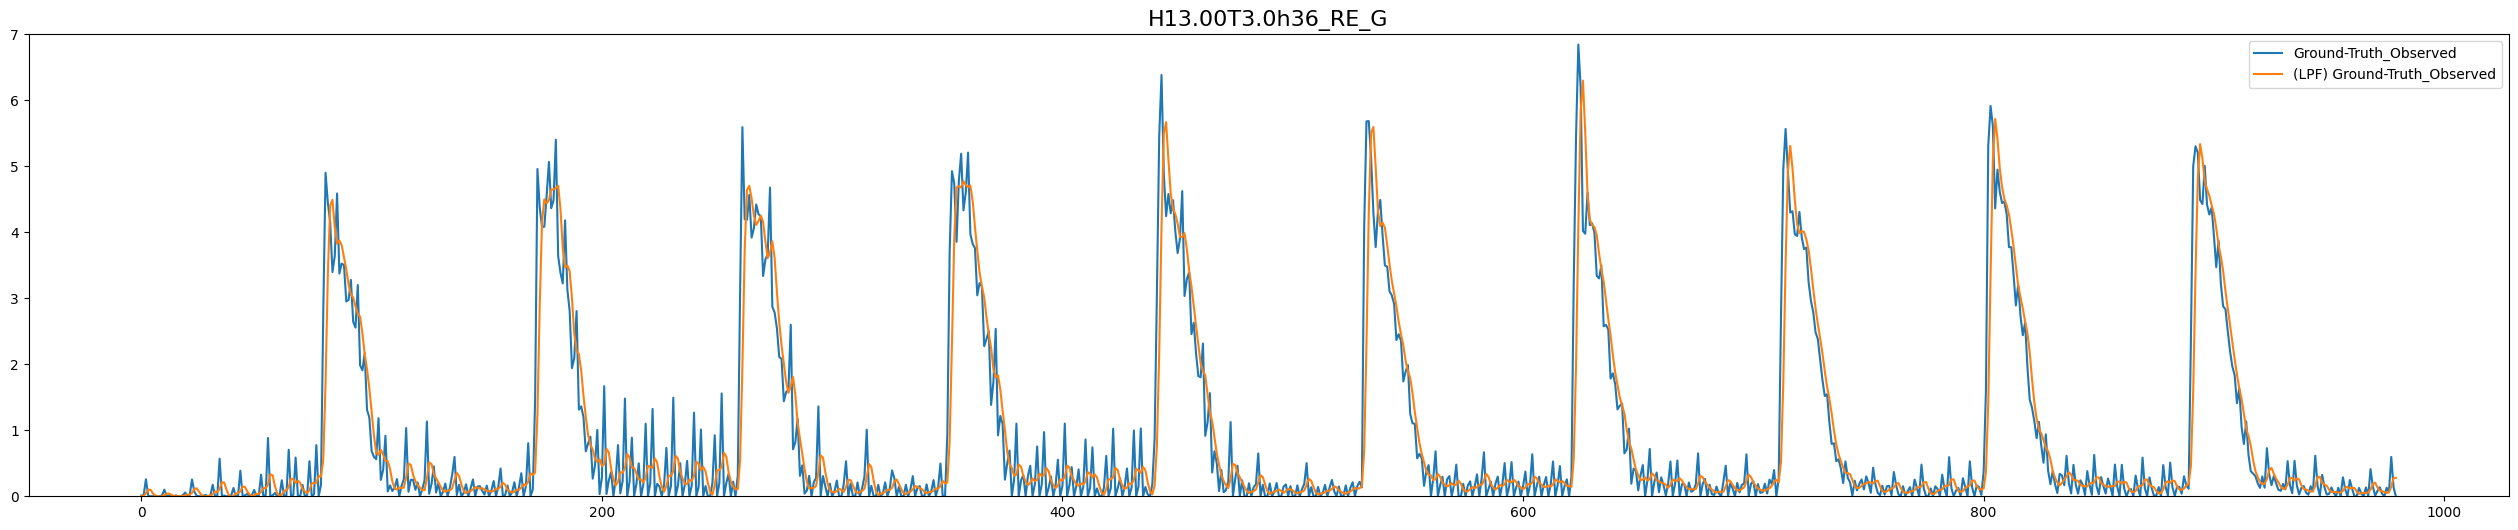

In [14]:
gt_sync_lpf = np.column_stack([gt_sync[:, 0], low_pass_filter(gt_sync[:, 1], 0.3, 2)])
show_height_graph_multiple([[gt_sync, "Ground-Truth_Observed"], [gt_sync_lpf, "(LPF) Ground-Truth_Observed"]], f"{sequence_name}", fig_size=(32, 6), font_size=10)

# Show Result (LPF)

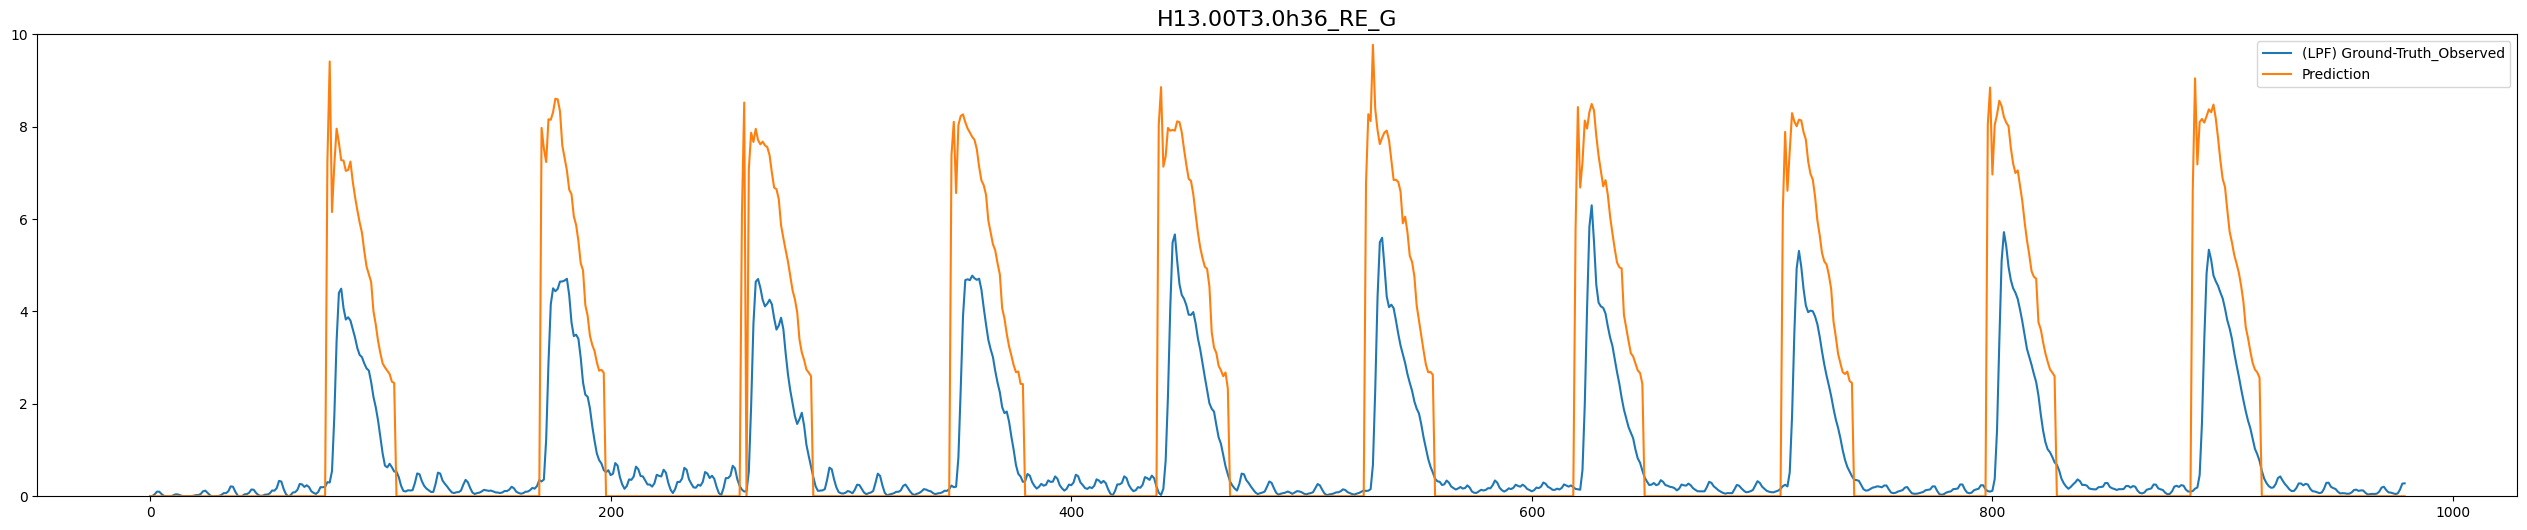

In [15]:
show_height_graph_multiple([[gt_sync_lpf, "(LPF) Ground-Truth_Observed"], [pr_sync, "Prediction"]], f"{sequence_name}", fig_size=(32, 6), font_size=10)